Takes the GMSTs of various paleotemperature curves and matches them to the plasim-genie model that most closely resembles it

In [10]:
import imageio
import glob
from gplately import pygplates
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
import pygmt
import re
import shutil
import sys
import xarray as xr

In [11]:
ages = list(np.arange(0,260,10)) # Ages that we simulated temperature for
var = 'puma_temperature_surface_air' #variable name to get aves from (probably air temp)

colours = ['plum','lightblue','salmon','yellowgreen','blue','red','green','cyan','orange','pink']

# Scotese (2021) paleotemperature data (from publication's supplementary data)
scotese = '/Users/jono/Documents/Databases/scotese2021_paleotemps/Part 4. Phanerozoic_Paleotemperature_Summaryv4.xlsx'

phanDA = '/Users/jono/Documents/Databases/PhanDA_GMSTandCO2_percentiles.csv'

merdithSCION = '/Users/jono/Documents/Databases/Merdith2024/ALL_ON_r=1000_2025Feb13.obj'

import importlib.util
import sys

pySCION_path = '/Users/jono/Documents/Databases/Merdith2024/pySCION_classes.py'
spec = importlib.util.spec_from_file_location("pySCION_classes", pySCION_path)
pySCION_classes = importlib.util.module_from_spec(spec)
sys.modules["pySCION_classes"] = pySCION_classes
spec.loader.exec_module(pySCION_classes)

# Get the paths to the climate models
model_path = '/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign'
climateModel = '2024-07-23_earthbyte_paleo_PaleomagRef' # Name of the climate model to use
climateModel = '2024-10-08_realigned_scotese_paleo_shallowSea'
co2s=['100','200','280','560','1120','2240','4480','fosterCO2']
models=[]
for co2 in co2s:
    model = os.path.join(model_path,f'{climateModel}_{co2}')
    # model = os.path.join(model_path,f'2024-10-08_scotese_paleo_{co2}ppm_shallowSea_{co2}')

    models.append(model)

In [ ]:
def process_merdith(file, ages):
    results = []
    with open(file, 'rb') as file_:
        results.append(pickle.load(file_))
    result = results[0]
    times = np.abs(np.mean(result[0].time_myr, axis=0))
    temps = np.mean(result[0].T_gast, axis=0)

    df = pd.DataFrame({'Age': times, 'paleoTemp': temps})
    agesDF = pd.DataFrame({'Age': ages}) # Create a dataframe with the ages we are interested in
    df = pd.concat([df, agesDF], ignore_index=True) # Concatenate the two dataframes
    df = df.set_index('Age').sort_index()

    df = df.interpolate(method='linear', axis=0).reset_index() # Interpolate the data to fill in missing values

    df = df[df['Age'].isin(ages)].set_index('Age')

    #remove duplicate first row if it exists and keep second row
    df = df[~df.index.duplicated(keep='last')]

    label = 'Merdith2024_pyscion'
    return df, label

def process_scotese(file, ages):
    """
    Process the Scotese data to extract temperature values for specified ages.
    """
    scoteseVar = pd.read_excel(file, '1my version')  # Read the specific sheet
    df = scoteseVar[scoteseVar['Age'].isin(ages)][['Age', 'GAT']].set_index('Age').rename(columns={'GAT': 'paleoTemp'})
    
    label = "Scotese2021_paleotemps"
    return df, label

def process_phanDA(csv, ages):
    """
    Process the PhanDA CSV file to extract temperature and CO2 data.
    """
    df = pd.read_csv(csv)
    agesDF = pd.DataFrame({'AverageAge': ages}) # Create a dataframe with the ages we are interested in
    df = pd.concat([df, agesDF], ignore_index=True) # Concatenate the two dataframes
    df = df.set_index('AverageAge').sort_index() # Set the index to the age column
    df = df.drop(columns=['Period','Epoch','Stage'])
    df = df.interpolate(method='linear', axis=0).reset_index() # Interpolate the data to fill in missing values

    df[df['AverageAge'] == 0] = df.iloc[1] # Make AverageAge = 0 the same values as the second row
    df.iloc[0,0] = 0 # Set the first age to 0

    # Just take the data we need
    df = df[df['AverageAge'].isin(ages)][['AverageAge', 'GMST_50']].set_index('AverageAge').rename(columns={'GMST_50': 'paleoTemp'})

    label = "PhanDA_paleotemps"
    return df, label

In [15]:
# df,paleoTempLabel = process_phanDA(phanDA, ages)
# df,paleoTempLabel = process_merdith(merdithSCION, ages)
df,paleoTempLabel = process_scotese(scotese, ages)
df


,paleoTemp
Age,
0.0,14.500000
10.0,16.251666
20.0,17.326809
30.0,17.935121
40.0,21.426648
50.0,25.140929
60.0,22.580030
70.0,21.105640
80.0,22.041626


In [22]:
# Add the GMST for each model run
for i in range(len(models)):
    model = models[i]
    co2 = co2s[i]
    for age in ages:
        plasimGrid = f'{model}/{str(age)}Ma_nc_outputs/3000-12-30_plasim.nc'

        if not os.path.exists(plasimGrid):
            print(f'{plasimGrid} does not exist, continuing but this may not work')
            continue

        info = pygmt.grdinfo(grid=f'{plasimGrid}?{var}', per_column=True, force_scan='2',verbose="e")

        mean = round(float(info.split()[10]), 4)

        df.at[age,co2] = mean

df

/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-10-08_realigned_scotese_paleo_shallowSea_100/0Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-10-08_realigned_scotese_paleo_shallowSea_100/10Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-10-08_realigned_scotese_paleo_shallowSea_100/20Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-10-08_realigned_scotese_paleo_shallowSea_100/30Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateMode

,paleoTemp
Age,
0.0,14.500000
10.0,16.251666
20.0,17.326809
30.0,17.935121
40.0,21.426648
50.0,25.140929
60.0,22.580030
70.0,21.105640
80.0,22.041626


'100'
'200'
'280'
'560'
'1120'
'2240'
'4480'
'fosterCO2'


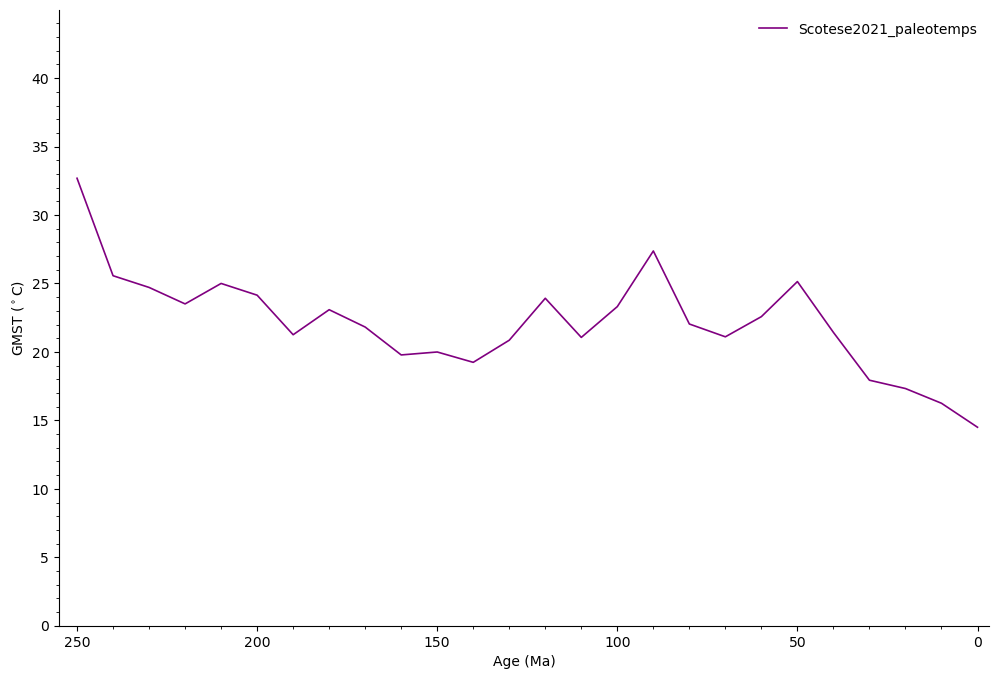

In [20]:
outdir = 'co2_GMST'
if os.path.exists(outdir):
    shutil.rmtree(outdir)
os.makedirs(outdir)

fig, ax = plt.subplots(figsize=(12,8))

# Set Y-axis limits
ax.set_ylim(0, 45)
ax.set_xlim(255,-3.2)

# Add tick marks for the Y-axis
ax.set_yticks(np.arange(0, 45, 5))
ax.set_xticks(np.arange(0, 251, 50))

ax.set_yticks(np.arange(0, 44.5, 1), minor=True)
ax.set_xticks(np.arange(0, 251, 10), minor=True)

# Customize grid appearance
ax.xaxis.remove_overlapping_locs = False
ax.yaxis.remove_overlapping_locs = False

ax.set_xlabel('Age (Ma)')
ax.set_ylabel('GMST ($^\circ$C)')

i=0
for co2 in co2s:
    # print(co2)
    try:
        ax.scatter(x=df.index,y=df[co2], marker='*', facecolors=colours[i], edgecolors='black', linewidths=1.25, s=250,  label=f'{co2} ppm')
    except Exception as e:
       print(e)
       pass
    co2name = co2
    try:
        int(co2)
    except Exception as e:
        # print(e)
        co2name = 'fosterCO2'
    # Hide the right and top spines
    ax.spines[['right', 'top']].set_visible(False)
    
    i+=1


ax.plot(df.index, df['paleoTemp'], linewidth=1.2, color='purple', linestyle='-', label=paleoTempLabel)
ax.legend(loc='upper right', ncol=2, frameon=False) 
plt.savefig(f'{outdir}/{paleoTempLabel}_gmst_comparison.png')

In [19]:
# New dataframe that has how far each simulation is off the Scotese reconstruction
dfDiff = pd.DataFrame()
for co2 in co2s:
    dfDiff[co2] = np.abs(df['paleoTemp'] - df[co2])

# Create a dictionary that has the closest match model for each age
modelDict = {}
for age in dfDiff.index:
    closestModel = dfDiff.loc[age].idxmin()
    modelDict[age] = closestModel

modelDict # Dictionary of model to use that is closest to Scotese global temps for each age


KeyError: '100'

100
200
280
560
1120
2240
4480
fosterCO2


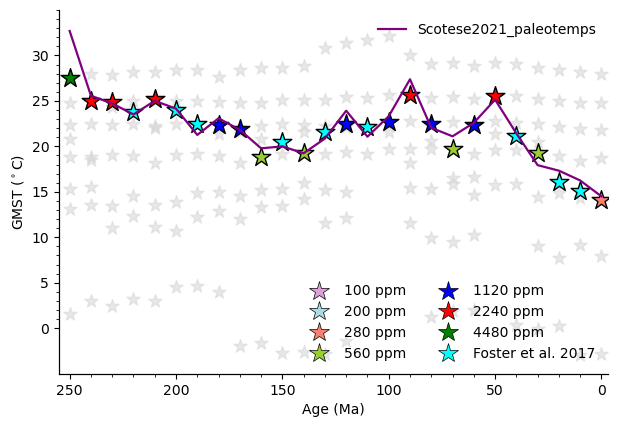

In [ ]:
colours = ['plum','lightblue','salmon','yellowgreen','blue','red','green','cyan','orange','pink']
colourDict = {}
import matplotlib.lines as mlines
markers = []
labels = []
for i in range(len(co2s)):
    co2 = co2s[i]
    colour = colours[i]
    colourDict[co2] = colour

    # Legend
    marker = mlines.Line2D([], [], color=colour, marker='*', linestyle='None', markersize=15, markeredgewidth=0.5, markeredgecolor='black', label=f'{co2}')
    markers.append(marker)

    if co2 == 'fosterCO2':
        label = 'Foster et al. 2017'
    else:
        label = f'{co2} ppm'
    labels.append(label)
mm = 1/25.4  # mm in inches
fig, ax = plt.subplots(figsize=(180*mm,120*mm))

# Set Y-axis limits
ax.set_ylim(-5, 35)
ax.set_xlim(255,-3.2)

# Add tick marks for the Y-axis
ax.set_yticks(np.arange(0, 35, 5))
ax.set_xticks(np.arange(0, 251, 50))

ax.set_yticks(np.arange(0, 35.5, 1), minor=True)
ax.set_xticks(np.arange(0, 251, 10), minor=True)

# Customize grid appearance
ax.xaxis.remove_overlapping_locs = False
ax.yaxis.remove_overlapping_locs = False

ax.plot(df.index, df['paleoTemp'], linewidth=1.6, color='purple', linestyle='-', label=paleoTempLabel
        )
i=0
for i in range(len(co2s)):
    co2 = co2s[i]
    print(co2)
    try:
        ax.scatter(x=df.index,y=df[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=1, s=100, alpha=0.5)
    except:
        continue
    i+=1
for age in modelDict:
    co2 = modelDict[age]
    try:
        ax.scatter(x=age,y=df.loc[age,co2], marker='*', facecolors=colourDict[co2], edgecolors='black', linewidths=1, s=200)
    except:
        continue
    

ax.set_xlabel('Age (Ma)')
ax.set_ylabel('GMST ($^\circ$C)')

# Hide the right and top spines
ax.spines[['right', 'top']].set_visible(False)

ax.legend(markers, labels, loc='best', ncol=2, frameon=False)

ax2 = ax.twinx()
ax2.plot(np.NaN, np.NaN, linewidth=1.6, color='purple', linestyle='-', label=paleoTempLabel)
ax2.get_yaxis().set_visible(False)
ax2.spines[['right', 'top']].set_visible(False)

ax2.legend(frameon=False)

plt.savefig(f'gmst_comparison_optimum.png', dpi=300)









In [ ]:
# Write the modelDict to a txt file
with open(f'preferredCO2_{climateModel}_{paleoTempLabel}.txt', 'w') as f:
    for age, model in modelDict.items():
        f.write(f'{age}\t{model}\n')